# Exploratory Data Analysis

The goal of this notebook is to understand what is in `customer_info.csv` and `customer_basket.csv` before we touch any modelling. We are looking for three things:

1. **Data quality issues** that need to be cleaned before clustering (impossible values, missingness patterns, mistyped columns).
2. **Distributional structure** that will inform our preprocessing choices (skew, outliers, encoding).
3. **Early hints at customer segments** so we know roughly what to expect from the clustering step.



## Setup

In [1]:
import sys
from pathlib import Path

# Make the project root importable
sys.path.insert(0, str(Path.cwd().parent))

import warnings
# Silence only the two known-noisy third-party categories rather than every
# warning: a blanket ignore hides real deprecations until they become errors.
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
warnings.filterwarnings("ignore", category=UserWarning, module="joblib")
warnings.filterwarnings("ignore", message=".*force_all_finite.*")

import re
import ast
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import preprocessing as pp
from src import visualization as viz
from src import config as cfg


In [2]:
# All figures are saved to `outputs/figures/` so they can be reused in the report without needing to be regenerated. 
# If you want to regenerate a figure, just run the notebook cell that creates it and it will be saved automatically.

viz.set_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

# Where to save figures
FIG_DIR = cfg.FIGURE_DIR
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    """Helper to save a figure into outputs/figures and keep it displayed."""
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=120, bbox_inches="tight")
    print(f"saved: {path.relative_to(cfg.PROJECT_ROOT)}")

## 1. Loading the data

`customer_info.csv` is one row per customer. `customer_basket.csv` is one row per transaction, with the items stored as a string-encoded list.

In [3]:
customers = pp.load_customer_info()
print("customer_info shape:", customers.shape)
customers.head(3)

customer_info shape: (33038, 25)


,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,28.0,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,43.0,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,118.0,1265.0,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656


In [4]:
baskets = pd.read_csv(cfg.RAW_CUSTOMER_BASKET)
baskets["items"] = baskets["list_of_goods"].apply(ast.literal_eval)
print("customer_basket shape:", baskets.shape)
baskets.head(3)

customer_basket shape: (100000, 4)


,invoice_id,list_of_goods,customer_id,items
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912,"[chicken, rice, pepper, whole wheat rice, shri..."
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853,"[low fat yogurt, tomatoes, pepper, asparagus, ..."
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19,"[cake, tomatoes, pancakes, iPad, final fantasy..."


Two sanity checks before going further: `customer_id` should be unique inside `customer_info`, and basket customers should be a subset of info customers.

In [5]:
info_ids = set(customers["customer_id"])
basket_ids = set(baskets["customer_id"])

print("Duplicate customer_ids in customer_info:", customers["customer_id"].duplicated().sum())
print("Customers in info with no basket:", len(info_ids - basket_ids))
print("Customers in baskets but not in info:", len(basket_ids - info_ids))

Duplicate customer_ids in customer_info: 0
Customers in info with no basket: 4911
Customers in baskets but not in info: 0


About 4,900 customers have no basket data. They will still get a final cluster assignment (clustering uses `customer_info`), but they will not contribute to per-segment association rules.

## 2. Data quality findings

Before any analysis, we walk through every issue that will trip up clustering.

### 2.1 Missing values

The interesting observation is not just *that* things are missing, but *how* they are missing.

In [6]:
missing = customers.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_df = pd.DataFrame({"missing": missing, "pct": (missing / len(customers) * 100).round(2)})
missing_df

,missing,pct
loyalty_card_number,13106,39.67
lifetime_spend_fish,991,3.00
number_complaints,661,2.00
lifetime_spend_vegetables,661,2.00
lifetime_spend_meat,661,2.00
lifetime_spend_videogames,661,2.00
typical_hour,661,2.00
lifetime_spend_electronics,661,2.00
lifetime_spend_petfood,661,2.00
distinct_stores_visited,330,1.00


saved: outputs/figures/01_missingness.png


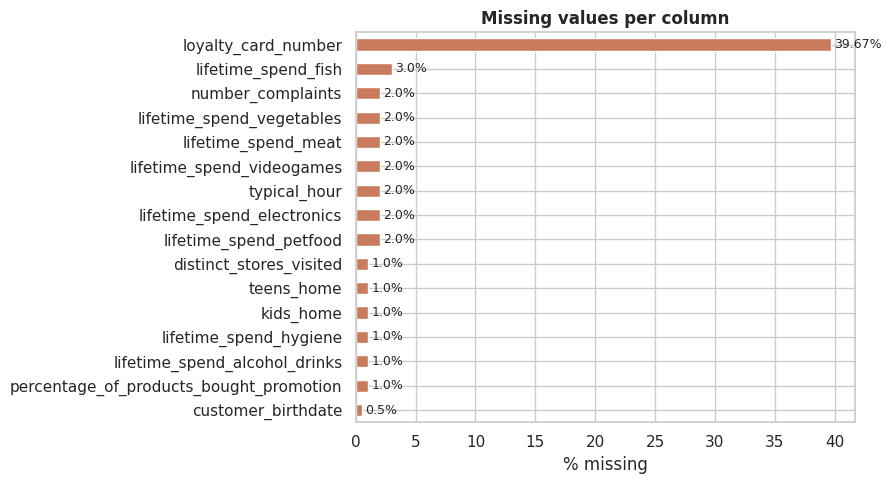

In [7]:
# Visualise the missingness pattern
fig, ax = plt.subplots(figsize=(9, 5))
missing_df["pct"].plot(kind="barh", ax=ax, color="#c97c5d")
ax.set_xlabel("% missing")
ax.set_title("Missing values per column")
ax.invert_yaxis()
for i, v in enumerate(missing_df["pct"]):
    ax.text(v + 0.3, i, f"{v}%", va="center", fontsize=9)
plt.tight_layout()
save_fig(fig, "01_missingness")
plt.show()

Notice the recurring counts; 330, 661, 991. These are clean multiples (roughly 1%, 2%, 3% of the data) and they show up across many columns. That is not random. We will impute everything, but it is worth flagging in the report that the missingness is structural, not random.

`loyalty_card_number` is in a category of its own with 40% missing. Looking at its non-null values explains why:

In [8]:
customers["loyalty_card_number"].dropna().unique()

array([1.])

The column only ever holds the value 1.0. As a numeric feature it carries no information. The signal lives in the presence/absence pattern, so we will transform this into a binary `has_loyalty_card` flag during preprocessing.

### 2.2 Impossible values: future first-transaction year

`year_first_transaction` should be in the past. The top of the distribution tells a different story.

In [9]:
year_counts = customers["year_first_transaction"].value_counts().sort_index()
year_counts.tail(10)

year_first_transaction
2020.0    1552
2021.0    3125
2022.0      78
2023.0     139
2024.0     204
2025.0     215
2026.0     305
2027.0     340
2028.0     293
2029.0     358
Name: count, dtype: int64

saved: outputs/figures/02_future_years.png


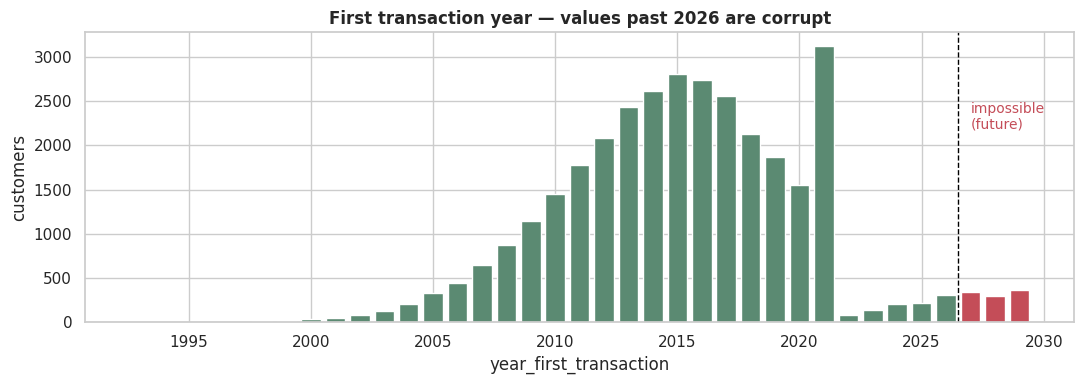

Rows with year > 2026 (impossible): 991 (3.0%)


In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#5b8a72" if y <= 2026 else "#c44d58" for y in year_counts.index]
ax.bar(year_counts.index, year_counts.values, color=colors)
ax.axvline(2026.5, color="black", linestyle="--", linewidth=1)
ax.text(2027, year_counts.max() * 0.7, "impossible\n(future)", color="#c44d58", fontsize=10)
ax.set_xlabel("year_first_transaction")
ax.set_ylabel("customers")
ax.set_title("First transaction year — values past 2026 are corrupt")
plt.tight_layout()
save_fig(fig, "02_future_years")
plt.show()

future = (customers["year_first_transaction"] > 2026).sum()
print(f"Rows with year > 2026 (impossible): {future} ({future/len(customers)*100:.1f}%)")

Almost 3% of customers have a first transaction recorded in 2027 to 2029. We are in May 2026, so anything past 2026 is data corruption. We will clip these to 2026 during preprocessing rather than drop the rows, since the rest of those customers' data looks fine.

### 2.3 Impossible values: negative promo percentage

A percentage cannot be negative.

In [11]:
promo = customers["percentage_of_products_bought_promotion"]
print(f"Range: {promo.min():.3f} to {promo.max():.3f}")
print(f"Negative count: {(promo < 0).sum()}")
print(f"Exactly 1.0:   {(promo == 1.0).sum()}")

Range: -1.275 to 1.000
Negative count: 1755
Exactly 1.0:   1207


saved: outputs/figures/03_promo_distribution.png


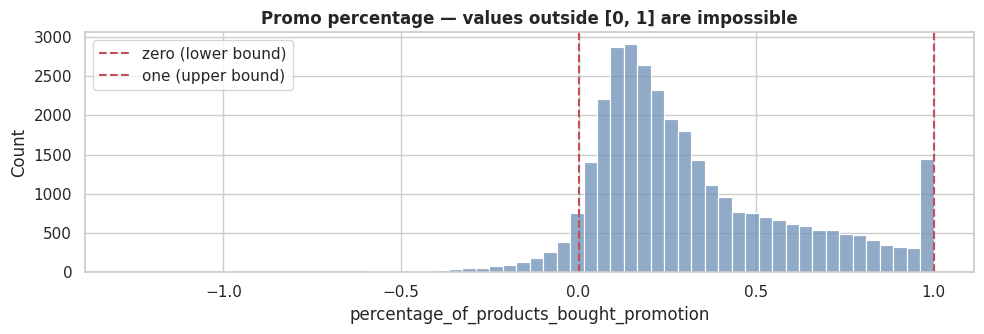

In [12]:
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.histplot(promo.dropna(), bins=60, ax=ax, color="#6c8eb6")
ax.axvline(0, color="#c44d58", linestyle="--", label="zero (lower bound)")
ax.axvline(1, color="#c44d58", linestyle="--", label="one (upper bound)")
ax.set_xlabel("percentage_of_products_bought_promotion")
ax.set_title("Promo percentage — values outside [0, 1] are impossible")
ax.legend()
plt.tight_layout()
save_fig(fig, "03_promo_distribution")
plt.show()

1,755 customers (around 5%) have negative promo percentages, going as low as -1.27. The 1,207 customers exactly at 1.0 are plausible, these are people who always shop on promotion. We will clip everything to [0, 1] in preprocessing.

### 2.4 Hidden information in `customer_name`

The project brief mentions that names contain a degree level. Looking at the data confirms it.

In [13]:
customers["customer_name"].head(10).tolist()

['Bsc. Crystal Kitchens',
 'Bsc. Glenda Bauman',
 'Msc. Antonio Campbell',
 'John Kelling',
 'Arthur Dematteo',
 'Msc. Nadine Garcia',
 'Phd. Franklin Alba',
 'Bsc. Robert Hansing',
 'Phd. Dorothy Pacheco',
 'Msc. Arron Burgener']

In [14]:
# Extract degree using a readable regex
degree_pattern = re.compile(r"^(Bsc|Msc|Phd)\.\s", flags=re.IGNORECASE)

def get_degree(name):
    if not isinstance(name, str):
        return "None"
    match = degree_pattern.match(name)
    return match.group(1).capitalize() if match else "None"

customers["degree"] = customers["customer_name"].apply(get_degree)
customers["degree"].value_counts()

degree
None    17731
Bsc      5154
Phd      5096
Msc      5057
Name: count, dtype: int64

Non-graduates are the **majority** of the customer base (53.7%), with the three graduate levels splitting the remainder almost evenly (Bsc 15.6%, Phd 15.4%, Msc 15.3%). So this is not four balanced groups: it is one large non-graduate group and three small, amost equally-sized graduate groups. That imbalance matters later, because the demographic clustering is dominated by this single split. Worth checking whether degree correlates with spending behaviour:

In [15]:
spend_cols = [c for c in customers.columns if c.startswith("lifetime_spend_")]
customers["total_spend"] = customers[spend_cols].sum(axis=1)

degree_summary = customers.groupby("degree")[
    ["total_spend", "lifetime_spend_electronics", "lifetime_spend_videogames"]
].mean().round(0)
degree_summary

,total_spend,lifetime_spend_electronics,lifetime_spend_videogames
degree,,,
Bsc,25155.0,2165.0,258.0
Msc,25352.0,2214.0,258.0
None,22370.0,3278.0,472.0
Phd,24665.0,2118.0,264.0


saved: outputs/figures/04_degree_vs_spend.png


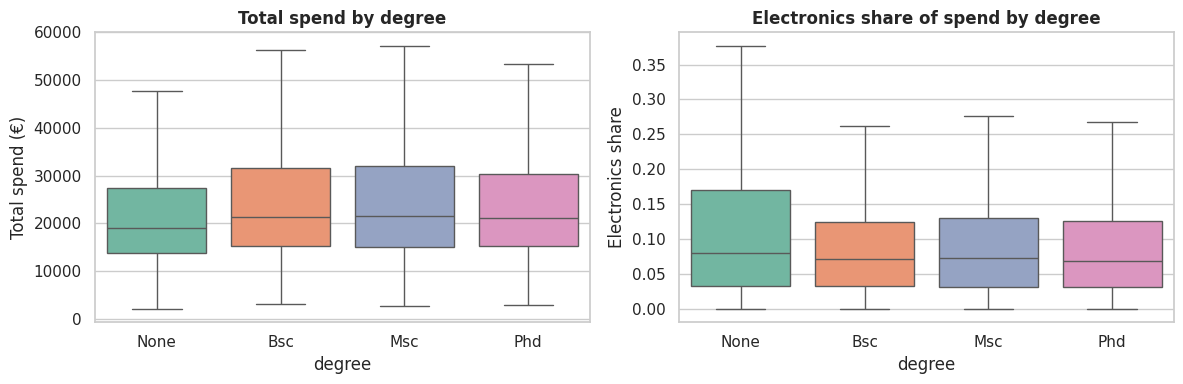

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Total spend by degree
order = ["None", "Bsc", "Msc", "Phd"]
sns.boxplot(data=customers, x="degree", y="total_spend", order=order, ax=axes[0],
            hue="degree", hue_order=order, palette="Set2", legend=False, showfliers=False)
axes[0].set_title("Total spend by degree")
axes[0].set_ylabel("Total spend (€)")

# Electronics share by degree
customers["electronics_share"] = customers["lifetime_spend_electronics"] / customers["total_spend"]
sns.boxplot(data=customers, x="degree", y="electronics_share", order=order, ax=axes[1],
            hue="degree", hue_order=order, palette="Set2", legend=False, showfliers=False)
axes[1].set_title("Electronics share of spend by degree")
axes[1].set_ylabel("Electronics share")

plt.tight_layout()
save_fig(fig, "04_degree_vs_spend")
plt.show()

The non-graduate group spends less in total but devotes a higher share to electronics. That hints at a younger or differently-profiled segment. Degree is going into the demographic perspective during clustering.

### 2.5 Date parsing

`customer_birthdate` is a string with `MM/DD/YYYY HH:MM AM/PM` format. The time portion is meaningless filler. We use the parsing function from `preprocessing.py` so the notebook and the pipeline always agree.

In [17]:
customers_with_age = pp.parse_birthdate(customers)
age = customers_with_age["age"]
customers["age"] = age  # keep on main df for downstream sections

print(f"Failed-to-parse + originally missing: {age.isna().sum()}")
print(f"Age range: {age.min():.1f} to {age.max():.1f}")
age.describe().round(1)

Failed-to-parse + originally missing: 165
Age range: 24.4 to 86.4


count    32873.0
mean        55.0
std         18.1
min         24.4
25%         39.1
50%         54.9
75%         70.7
max         86.4
Name: age, dtype: float64

saved: outputs/figures/05_age_distribution.png


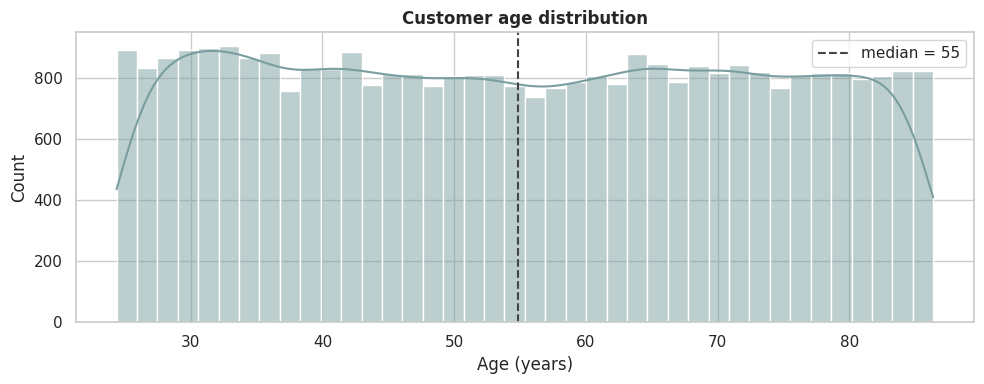

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(age.dropna(), bins=40, ax=ax, color="#7a9e9f", kde=True)
ax.axvline(age.median(), color="#444", linestyle="--", label=f"median = {age.median():.0f}")
ax.set_xlabel("Age (years)")
ax.set_title("Customer age distribution")
ax.legend()
plt.tight_layout()
save_fig(fig, "05_age_distribution")
plt.show()

The age distribution is strikingly **uniform** rather than bell-shaped: each ten-year band from 30 to 80 holds a near-constant 5,200 to 5,600 customers, with only the truncated tails (under 30, over 80) thinner. 

## 3. Distributional structure

We now look at the spend columns more carefully, since they will dominate the clustering.

In [19]:
customers[spend_cols].describe().T.round(0)

,count,mean,std,min,25%,50%,75%,max
lifetime_spend_groceries,33038.0,16306.0,11986.0,0.0,8647.0,13002.0,20807.0,104670.0
lifetime_spend_electronics,32377.0,2763.0,3453.0,0.0,579.0,1470.0,3745.0,35299.0
lifetime_spend_vegetables,32377.0,727.0,655.0,0.0,224.0,471.0,1074.0,3337.0
lifetime_spend_nonalcohol_drinks,33038.0,464.0,276.0,0.0,241.0,421.0,640.0,2180.0
lifetime_spend_alcohol_drinks,32708.0,622.0,518.0,0.0,201.0,483.0,891.0,3704.0
lifetime_spend_meat,32377.0,724.0,483.0,0.0,343.0,729.0,1010.0,3052.0
lifetime_spend_fish,32047.0,609.0,497.0,0.0,171.0,511.0,923.0,3172.0
lifetime_spend_hygiene,32708.0,820.0,608.0,0.0,362.0,686.0,1120.0,3482.0
lifetime_spend_videogames,32377.0,374.0,461.0,0.0,125.0,223.0,374.0,3936.0
lifetime_spend_petfood,32377.0,336.0,160.0,0.0,225.0,327.0,435.0,1224.0


All ten spend columns have a minimum of 0 and a heavy right tail. We use two complementary views, histograms with log y-axis to see the tail clearly, and boxplots to see where the outliers sit.

saved: outputs/figures/06_spend_histograms.png


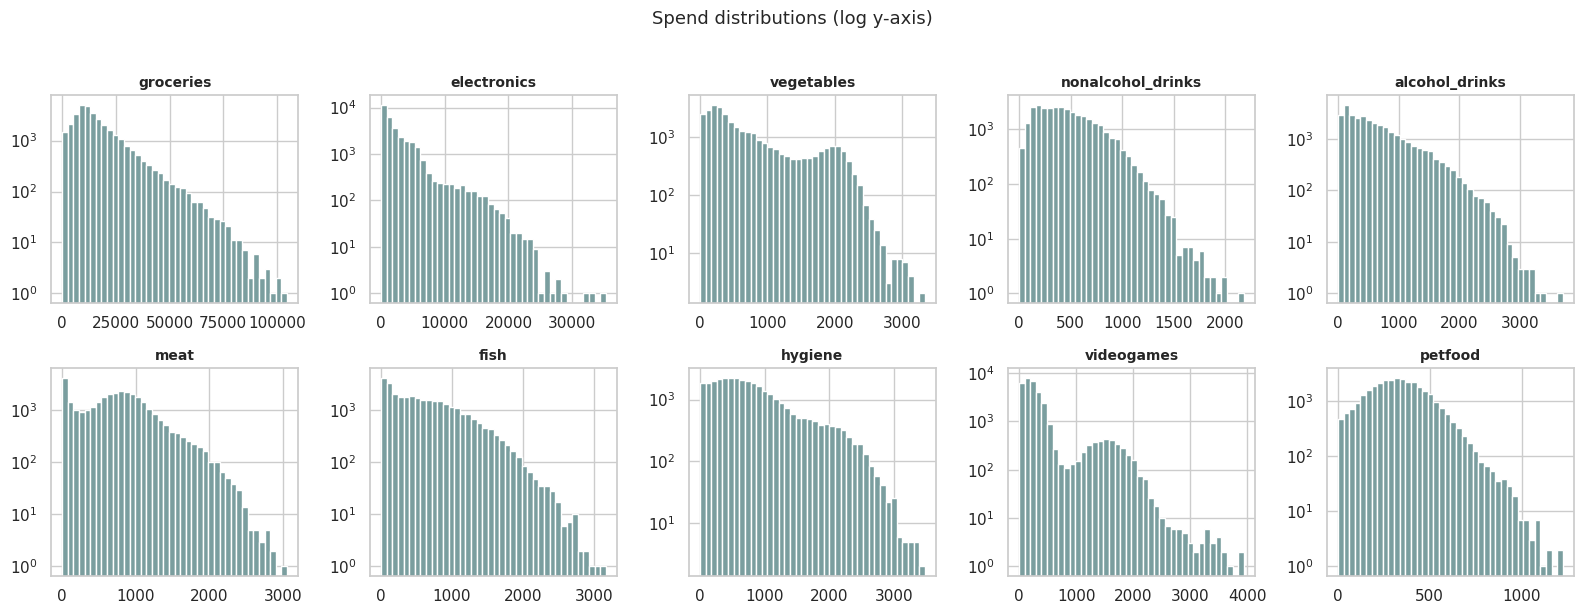

In [20]:
# Histograms on log y-axis
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, col in zip(axes.flatten(), spend_cols):
    customers[col].dropna().hist(bins=40, ax=ax, color="#7a9e9f")
    ax.set_title(col.replace("lifetime_spend_", ""), fontsize=10)
    ax.set_yscale("log")
    ax.set_ylabel("")
fig.suptitle("Spend distributions (log y-axis)", y=1.02, fontsize=13)
plt.tight_layout()
save_fig(fig, "06_spend_histograms")
plt.show()

saved: outputs/figures/07_spend_boxplots.png


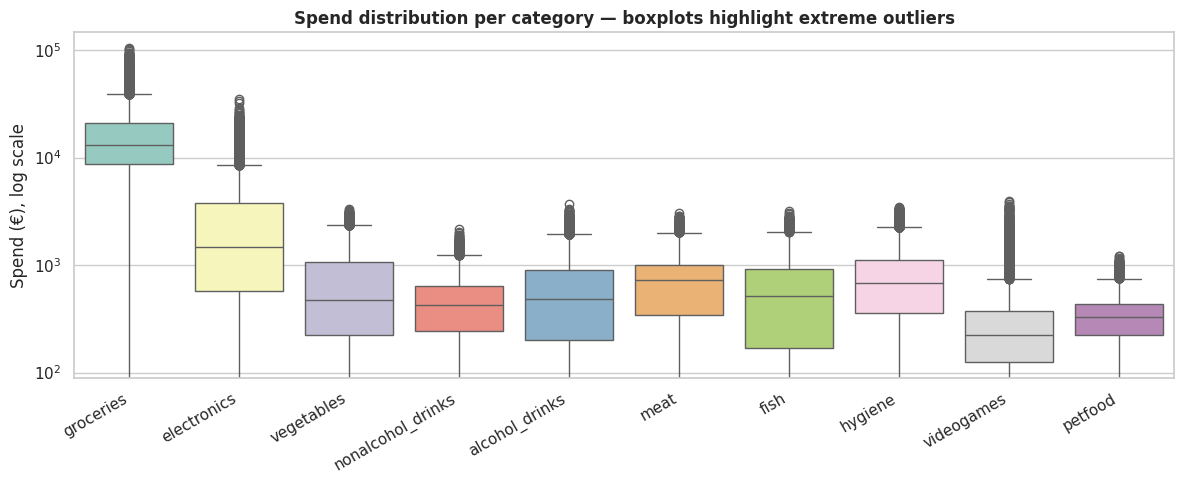

In [21]:
# Boxplots in € on a shared scale (using a melt for seaborn)
melted = customers[spend_cols].melt(var_name="category", value_name="spend")
melted["category"] = melted["category"].str.replace("lifetime_spend_", "")

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=melted, x="category", y="spend", ax=ax,
            hue="category", palette="Set3", legend=False)
ax.set_yscale("log")
ax.set_xlabel("")
ax.set_ylabel("Spend (€), log scale")
ax.set_title("Spend distribution per category — boxplots highlight extreme outliers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save_fig(fig, "07_spend_boxplots")
plt.show()

All categories are heavily right-skewed and groceries is the most extreme. The implications for preprocessing:

- **`lifetime_spend_groceries`** — span of more than four orders of magnitude. We log-transform.
- **Other spend columns** — tails are noisier and would dominate K-Means distance. We cap at the 99th percentile.
- **For the product-mix perspective**, we use *relative shares* (each category divided by total spend) which sidesteps the scale issue entirely.

### 3.1 Groceries dominates total spend

This single fact decides the design of the clustering.

In [22]:
correlations = customers[spend_cols + ["total_spend"]].corr()["total_spend"].drop("total_spend")
avg_share = (customers[spend_cols].mean() / customers["total_spend"].mean() * 100).round(1)

summary = pd.DataFrame({
    "avg_share_of_total_%": avg_share,
    "corr_with_total": correlations.round(3),
}).sort_values("avg_share_of_total_%", ascending=False)
summary

,avg_share_of_total_%,corr_with_total
lifetime_spend_groceries,69.1,0.946
lifetime_spend_electronics,11.7,0.351
lifetime_spend_hygiene,3.5,0.168
lifetime_spend_vegetables,3.1,-0.138
lifetime_spend_meat,3.1,0.444
lifetime_spend_alcohol_drinks,2.6,0.354
lifetime_spend_fish,2.6,0.478
lifetime_spend_nonalcohol_drinks,2.0,0.438
lifetime_spend_videogames,1.6,0.129
lifetime_spend_petfood,1.4,0.103


saved: outputs/figures/08_spend_shares.png


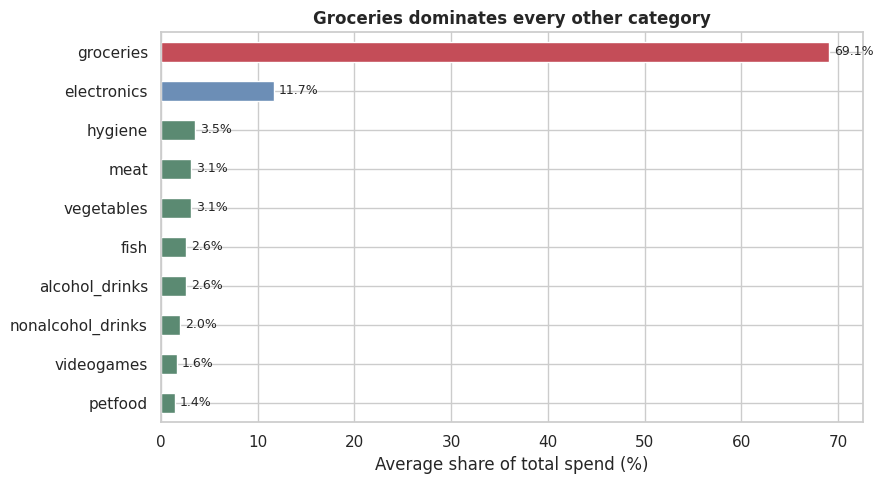

In [23]:
# Visualise the share of total spend per category
shares = summary["avg_share_of_total_%"].sort_values(ascending=True)
shares.index = shares.index.str.replace("lifetime_spend_", "")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#c44d58" if s > 50 else "#5b8a72" if s < 5 else "#6c8eb6" for s in shares]
shares.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Average share of total spend (%)")
ax.set_title("Groceries dominates every other category")
for i, v in enumerate(shares.values):
    ax.text(v + 0.5, i, f"{v}%", va="center", fontsize=9)
plt.tight_layout()
save_fig(fig, "08_spend_shares")
plt.show()

Groceries makes up 69% of average total spend and correlates 0.95 with it. If we cluster on raw spend columns, the result is essentially a wealth ranking dominated by groceries. To get behavioural segments, vegetable-lovers, tech enthusiasts, pet owners, we have to look at **relative** shares.

One observation worth mentioning : vegetables has a slightly *negative* correlation with total spend (-0.14). Heavier spenders devote less of their basket to vegetables. That is already a hint of a "convenience vs healthy" axis that the clustering might pick up.

### 3.2 Correlations between spend categories

A correlation heatmap shows which categories move together and which are independent.

saved: outputs/figures/09_spend_correlations.png


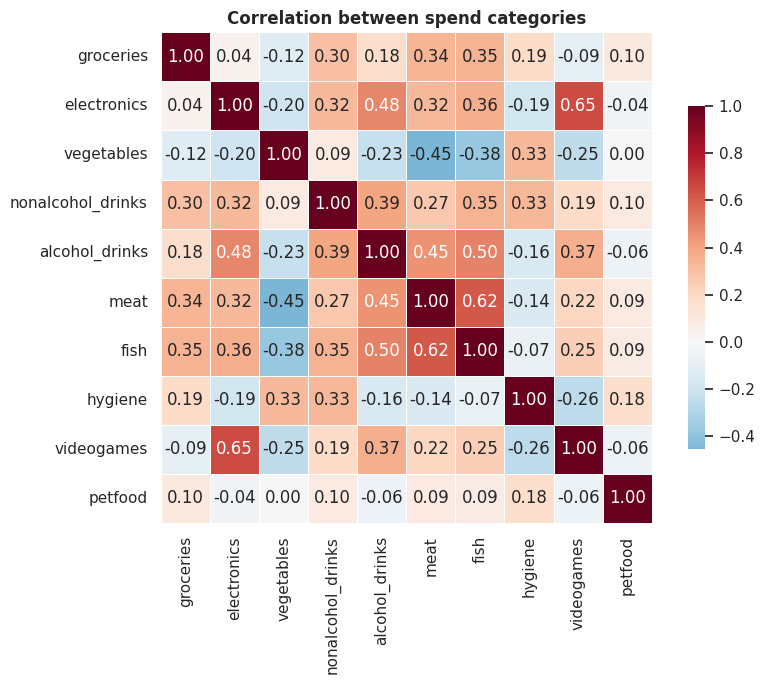

In [24]:
corr_matrix = customers[spend_cols].corr()
corr_matrix.index = corr_matrix.index.str.replace("lifetime_spend_", "")
corr_matrix.columns = corr_matrix.columns.str.replace("lifetime_spend_", "")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlation between spend categories")
plt.tight_layout()
save_fig(fig, "09_spend_correlations")
plt.show()

Reading the heatmap, the structure is richer than "everything is mildly correlated". Three things stand out:

- **Electronics and videogames move together most strongly (+0.65)** — the clearest positive pairing in the data, and the empirical basis for the later "tech" product-mix cluster. Meat and fish (+0.62) are the second pairing, the classic protein-shopper signal.
- **Vegetables sits on its own negative axis.** It is *negatively* correlated with meat (−0.45), fish (−0.38), videogames (−0.25) and alcohol (−0.23), and positively correlated only with hygiene (+0.33). In other words, the more a customer leans toward fresh vegetables and hygiene, the less they lean toward meat, fish, tech and alcohol. That is a genuine behavioural axis — a "fresh / household" tendency opposed to an "indulgence / tech" tendency — and it is exactly the kind of structure the product-mix clustering should pick up rather than a single wealth dimension.
- Everything else is mild (roughly 0.1 to 0.5), which is healthy: the categories carry largely independent information, so clustering on relative shares will find real behavioural groups rather than rediscovering one "how much do they spend" axis.

### 3.3 Family structure

saved: outputs/figures/10_family_structure.png


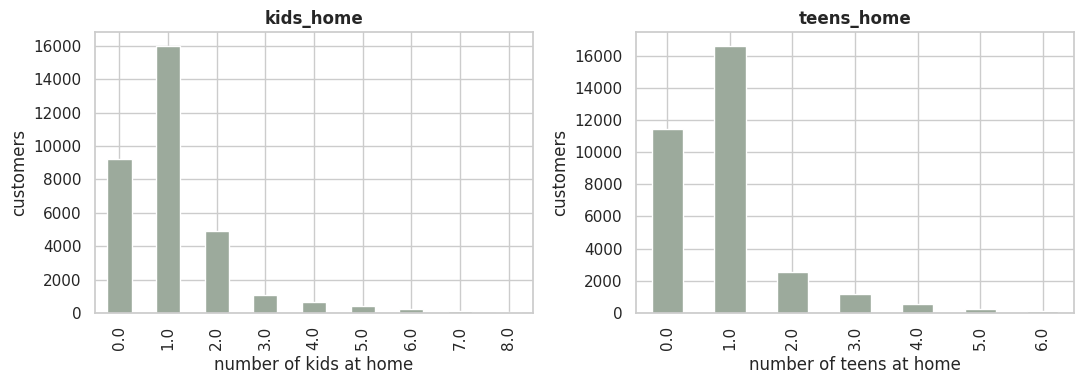

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
customers["kids_home"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#9caa9c")
axes[0].set_title("kids_home")
axes[0].set_xlabel("number of kids at home")
axes[0].set_ylabel("customers")

customers["teens_home"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#9caa9c")
axes[1].set_title("teens_home")
axes[1].set_xlabel("number of teens at home")
axes[1].set_ylabel("customers")

plt.tight_layout()
save_fig(fig, "10_family_structure")
plt.show()

Most customers have zero or one kid and zero or one teen at home. Long tail up to 8 kids, but very sparse. We will cap both at 4 in preprocessing to prevent rare large-family rows from dominating the demographic clustering.

### 3.3b Gender, complaints, and store loyalty

Three more features feed the demographic and value perspectives — customer gender, the number of complaints lodged, and how many distinct stores each customer has visited. They are worth a quick look before clustering.

saved: outputs/figures/10b_gender_complaints_stores.png


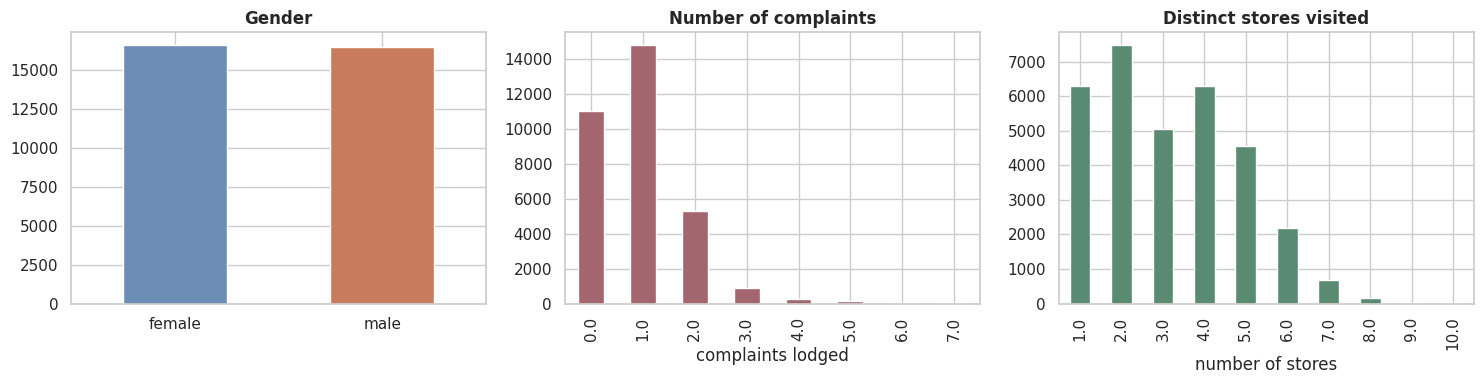

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

customers["customer_gender"].value_counts(dropna=False).plot(
    kind="bar", ax=axes[0], color=["#6c8eb6", "#c97c5d"])
axes[0].set_title("Gender")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

customers["number_complaints"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="#a4666e")
axes[1].set_title("Number of complaints")
axes[1].set_xlabel("complaints lodged")

customers["distinct_stores_visited"].value_counts().sort_index().plot(
    kind="bar", ax=axes[2], color="#5b8a72")
axes[2].set_title("Distinct stores visited")
axes[2].set_xlabel("number of stores")

plt.tight_layout()
save_fig(fig, "10b_gender_complaints_stores")
plt.show()

- **Gender** is almost exactly balanced (about 50.2% female, 49.8% male), so it is unlikely to drive segmentation on its own; we keep it as a binary feature but expect it to be a weak signal.
- **Complaints** are right-skewed: most customers have lodged none or one, a meaningful minority have two, and a small tail goes up to seven. The tail is the interesting part, a handful of persistently dissatisfied customers, though it is too small to form its own cluster.
- **Distinct stores visited** peaks at one to two stores and tapers to a thin tail at nine to ten. Customers who visit many stores are plausibly more mobile or more deal-driven (they shop around), which is why this feature sits in the value/engagement perspective rather than the demographic one. Both complaints and stores have a small number of missing values, imputed as described in the preprocessing notebook.

### 3.4 Shopping hour

saved: outputs/figures/11_typical_hour.png


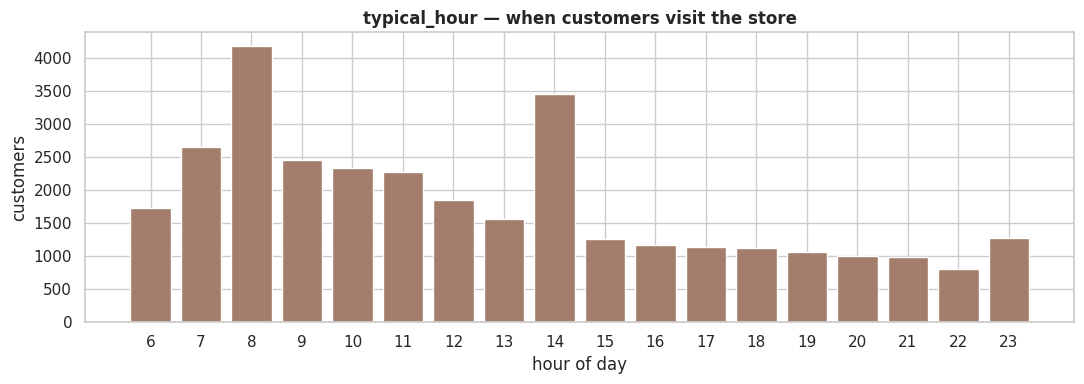

In [27]:
hour_counts = customers["typical_hour"].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(hour_counts.index, hour_counts.values, color="#a47e6c")
ax.set_xlabel("hour of day")
ax.set_ylabel("customers")
ax.set_title("typical_hour — when customers visit the store")
ax.set_xticks(range(6, 24))
plt.tight_layout()
save_fig(fig, "11_typical_hour")
plt.show()

The store only records visits between **06:00 and 23:00 — hours 0 to 5 are entirely absent** from the data, presumably because the stores are closed overnight. Within opening hours there is a clear morning concentration: the single busiest hour is 08:00, and roughly half of all customers have their typical visit before noon. There is a secondary bump at 14:00 (just after lunch) and a modest uptick in the final open hour, 23:00, but the overall shape is a long, gently declining afternoon-and-evening tail rather than a dramatic late-night spike. Because hour-of-day is bounded and cyclic, we encode it with sine and cosine in preprocessing, so 23:00 and 06:00 are treated as near neighbours rather than opposite extremes.

### 3.5 Geography

saved: outputs/figures/12_geography.png


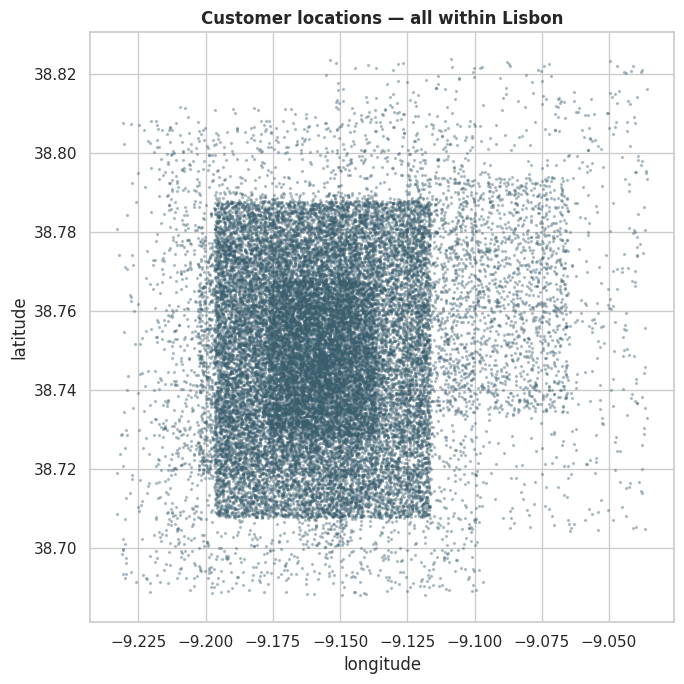

Latitude range:  38.688 to 38.824
Longitude range: -9.233 to -9.036


In [28]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(customers["longitude"], customers["latitude"], s=2, alpha=0.3, color="#3a5e6e")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("Customer locations — all within Lisbon")
plt.tight_layout()
save_fig(fig, "12_geography")
plt.show()

print(f"Latitude range:  {customers['latitude'].min():.3f} to {customers['latitude'].max():.3f}")
print(f"Longitude range: {customers['longitude'].min():.3f} to {customers['longitude'].max():.3f}")

All customers fall inside a tight **rectangle** of roughly 38.69 to 38.82 latitude and −9.23 to −9.04 longitude — essentially the Lisbon metropolitan area, about 15 km across. The points fill that box fairly evenly rather than clumping into neighbourhoods, which (like the uniform ages) hints the coordinates were sampled within a bounding box rather than drawn from real addresses. Either way the practical conclusion is the same: this is effectively a single geographic market, so latitude and longitude carry no segmentation signal and we exclude them from clustering.

### 3.6 Early segment hints: age vs total spend

Before clustering, we look at how spending relates to age. If we see clusters by eye, they will probably show up in the algorithm too.

saved: outputs/figures/13_age_vs_spend.png


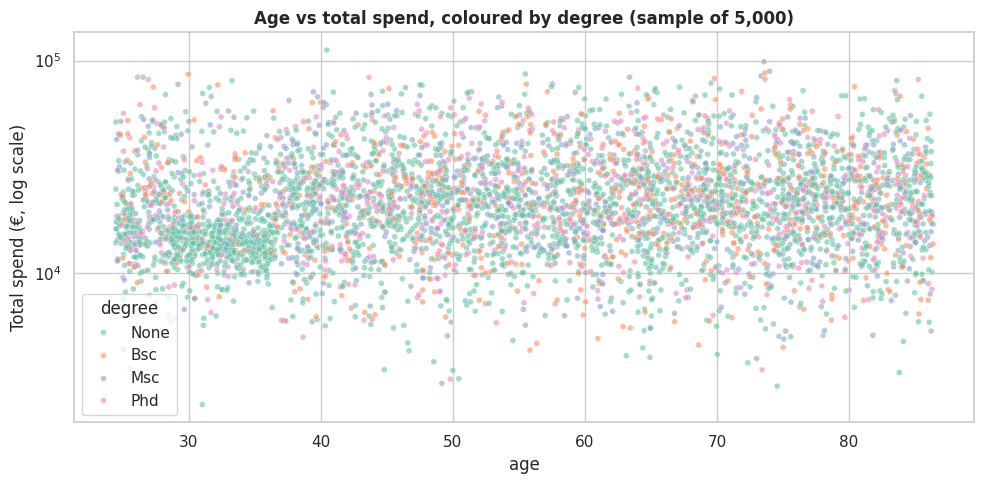

In [29]:
sample = customers.sample(min(5000, len(customers)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=sample, x="age", y="total_spend", hue="degree",
                hue_order=["None", "Bsc", "Msc", "Phd"],
                palette="Set2", alpha=0.6, s=18, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("age")
ax.set_ylabel("Total spend (€, log scale)")
ax.set_title("Age vs total spend, coloured by degree (sample of 5,000)")
ax.legend(title="degree")
plt.tight_layout()
save_fig(fig, "13_age_vs_spend")
plt.show()

Total spend is spread roughly evenly across ages on the log scale, which means age alone is not a strong driver of total spend. Degree separates spend a bit (the None group sits slightly lower). This reinforces the design choice: spending intensity and demographics should be clustered as independent perspectives.

## 4. The basket dataset

Quick overview of the basket file. We use it later for association rules per segment, not for the clustering itself.

In [30]:
basket_sizes = baskets["items"].apply(len)
all_items = [item for lst in baskets["items"] for item in lst]

print(f"Total baskets:                    {len(baskets):,}")
print(f"Distinct customers with baskets:  {baskets['customer_id'].nunique():,}")
print(f"Average basket size:              {basket_sizes.mean():.2f}")
print(f"Median basket size:               {int(basket_sizes.median())}")
print(f"Unique products in universe:      {len(set(all_items)):,}")

Total baskets:                    100,000
Distinct customers with baskets:  28,127
Average basket size:              9.40
Median basket size:               9
Unique products in universe:      164


saved: outputs/figures/14_basket_sizes.png


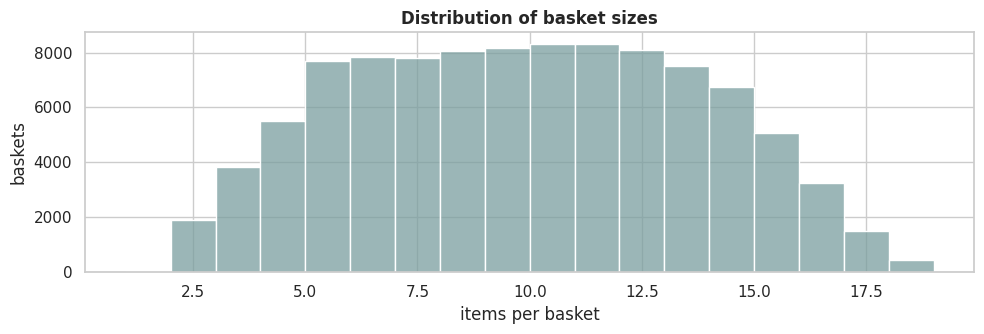

In [31]:
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.histplot(basket_sizes, bins=range(1, basket_sizes.max() + 2), ax=ax, color="#7a9e9f")
ax.set_xlabel("items per basket")
ax.set_ylabel("baskets")
ax.set_title("Distribution of basket sizes")
plt.tight_layout()
save_fig(fig, "14_basket_sizes")
plt.show()

saved: outputs/figures/15_top_products.png


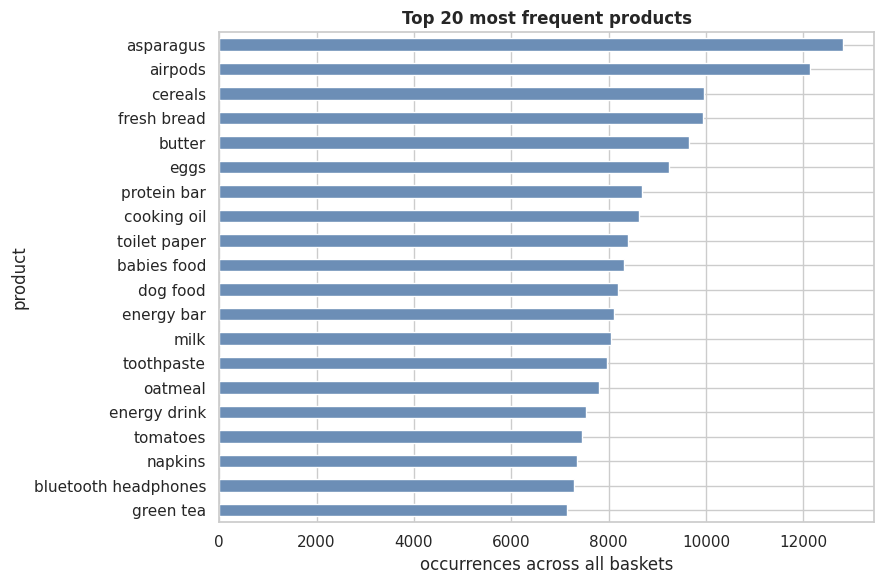

,product,occurrences
0,asparagus,12811
1,airpods,12145
2,cereals,9952
3,fresh bread,9934
4,butter,9654
5,eggs,9241
6,protein bar,8695
7,cooking oil,8623
8,toilet paper,8395
9,babies food,8318


In [32]:
top = Counter(all_items).most_common(20)
top_df = pd.DataFrame(top, columns=["product", "occurrences"])

fig, ax = plt.subplots(figsize=(9, 6))
top_df.set_index("product")["occurrences"].sort_values().plot(kind="barh", ax=ax, color="#6c8eb6")
ax.set_xlabel("occurrences across all baskets")
ax.set_title("Top 20 most frequent products")
plt.tight_layout()
save_fig(fig, "15_top_products")
plt.show()

top_df

164 unique products. The single most frequent item is **asparagus** (in 12,811 baskets), narrowly ahead of **airpods** (12,145) — a telling pair to top the list, because they point straight at two of the product-mix clusters we will find later. Asparagus, together with the fresh-bread / butter / cereals staples just behind it, is the basket-level fingerprint of the fresh-and-household shoppers that the spend-share data flags as the vegetables-and-hygiene (young-parents) cluster; airpods and the tech accessories around it are the fingerprint of the electronics-and-videogames cluster. Seeing these surface as the two most common products in the raw basket data, before any clustering, is early corroboration that those behavioural groups are real and not modelling artefacts. The 4,900 customers with no basket record will still be clustered on their customer_info features; they simply do not contribute to the association-rule mining in notebook 04.

## 5. Summary of preprocessing decisions

Pulling together everything we found into a single table that drives the next notebook:

| Issue | Decision |
|---|---|
| `customer_birthdate` is string with format `MM/DD/YYYY hh:mm AM/PM` | Parse to age in years, median-impute the 165 missing |
| `customer_name` contains degree prefix | Extract into a `degree` column with values Bsc / Msc / Phd / None |
| `loyalty_card_number` only ever 1.0 or NaN | Convert to binary `has_loyalty_card` |
| `year_first_transaction` has 991 future values | Clip to 2026, then derive `tenure_years` |
| `percentage_of_products_bought_promotion` has 1,755 negative values | Clip to [0, 1] |
| Spend columns have block-wise missingness | Fill with 0 (no record = no spend in that category) |
| `kids_home`, `teens_home`, `number_complaints` missing | Fill with 0 (no record = none) |
| `distinct_stores_visited`, `typical_hour` missing | Median-impute |
| Heavy right skew on spend | Log-transform `total_spend` (which groceries dominates); 99th-pct cap the other spend columns |
| `kids_home`, `teens_home` long tails | Cap at 4 |
| `typical_hour` is cyclic | Sine/cosine encoding |
| Lat/lon — single market | Exclude from clustering |

We also confirmed:

- 33,038 customers, all with unique IDs
- 100,000 baskets covering 28,127 customers
- Groceries makes up 69% of spending on average and correlates 0.95 with total spend, which is why **relative shares** are essential for product-mix clustering
- Demographics will be heavily influenced by the degree column; that is expected and useful
- 164 unique products in the basket data, with a clear over-representation of tech items (airpods at #2 overall)

Preprocessing is implemented in `src/preprocessing.py` and applied in the next notebook.